HISTOGRAMAS


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
 
def contraste (img, factor=1.0):
    img=img.astype(np.float32)
    media=np.mean(img)
    img_contraste=media+(img-media)*factor
    img_contraste=np.clip(img_contraste, 0, 255).astype(np.uint8)
    return img_contraste

img=cv2.imread('Fond.jpg',0)
contraste=7
img_fin = contraste(img, factor)

histograma_ori = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
histograma_new = cv2.calcHist([img_fin], [0], None, [256], [0, 256]).flatten()




    ##
plt.figure(figsize=(12, 6))
plt.subplot(221)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.subplot(222)
plt.plot(histograma_ori,color='gray')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma Original')
plt.subplot(223)
plt.imshow(img_fin, cmap='gray')
plt.title('Imagen con Contraste Ajustado')
plt.subplot(224)
plt.plot(histograma_new,color='gray')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.tight_layout()
    

TypeError: 'int' object is not callable

Calcular el histograma de un punto de interes de una imagen a colore

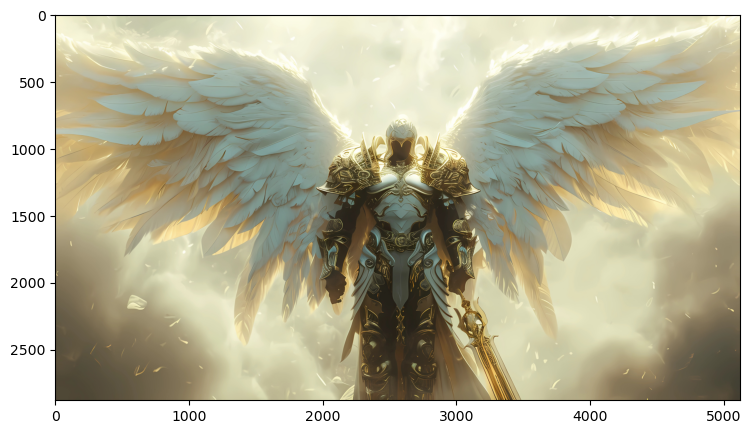

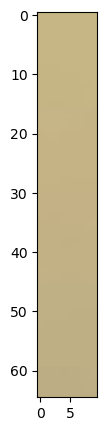

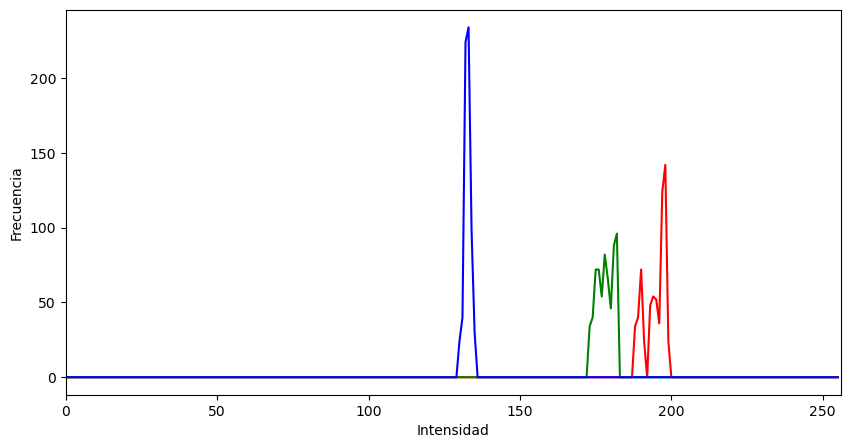

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imge= cv2.imread('Fond.jpg')
img_rgb = cv2.cvtColor(imge, cv2.COLOR_BGR2RGB)
plt.rcParams['figure.figsize'] = (10, 5)

plt.imshow(img_rgb)
plt.show()


plt.imshow(img_rgb[1500:1565,20:30:])
plt.show()


img_recortada = img_rgb[1500:1565,20:30]
plt.imsave('img_recortada.jpg', img_recortada)

img_fin=plt.imread('img_recortada.jpg')
color = ('r','g','b')
#Histograma por cada canal de color
for canal,col in enumerate(color):
    histograma = cv2.calcHist([img_fin],[canal],None,[256],[0,256])
    plt.plot(histograma,color=col)
    plt.xlabel('Intensidad')
    plt.ylabel('Frecuencia')
    plt.xlim([0,256])
plt.show()




ECUALIZACION DE UN HISTOGRAMA "Se desea normalizar una imagen a un punto optimo por histograma"

C:\Users\ASUS ROG\AppData\Local\Temp\ipykernel_161812\3699130948.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256],color='r')


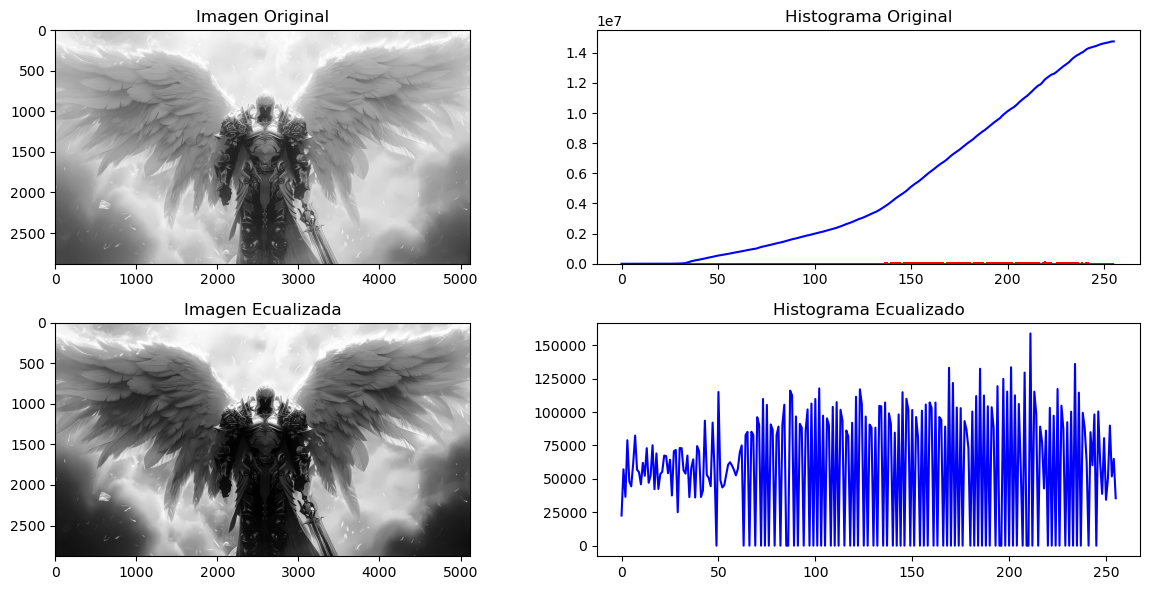

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Fond.jpg', 0)
histograma,calc=np.histogram(img.flatten(),256,[0,256])
distAcum=histograma.cumsum()
dis_norm=distAcum*histograma.max()/distAcum.max()
ecualizar=cv2.equalizeHist(img)

histograma_ecu,_=np.histogram(ecualizar.flatten(),256,[0,256])

#para un histrograma siempre en plot, no en show

plt.figure(figsize=(12, 6))
plt.subplot(221)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')

plt.subplot(222)
plt.plot(distAcum,color='b')
#Imprimir histograma por plt
plt.hist(img.flatten(),256,[0,256],color='r')
plt.title('Histograma Original')


plt.subplot(223)
plt.imshow(ecualizar, cmap='gray')  
plt.title('Imagen Ecualizada')

plt.subplot(224)
plt.plot(histograma_ecu,color='b')
plt.title('Histograma Ecualizado')
plt.tight_layout()


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Fond.jpg')

ecualizado=cv2.equalizeHist(img)
ecu_color=cv2.merge([cv2.equalizeHist(img[:,:,0]), cv2.equalizeHist(img[:,:,1]), cv2.equalizeHist(img[:,:,2])])

plt.imshow(ecualizado,cmap='gray')

plt.show()
plt.imshow(cv2.cvtColor(ecu_color, cv2.COLOR_BGR2RGB))
plt.show()




error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\histogram.cpp:3449: error: (-215:Assertion failed) _src.type() == CV_8UC1 in function 'cv::equalizeHist'


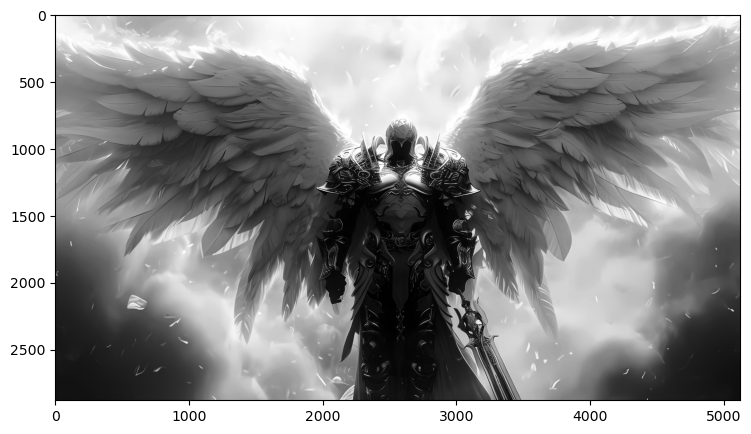

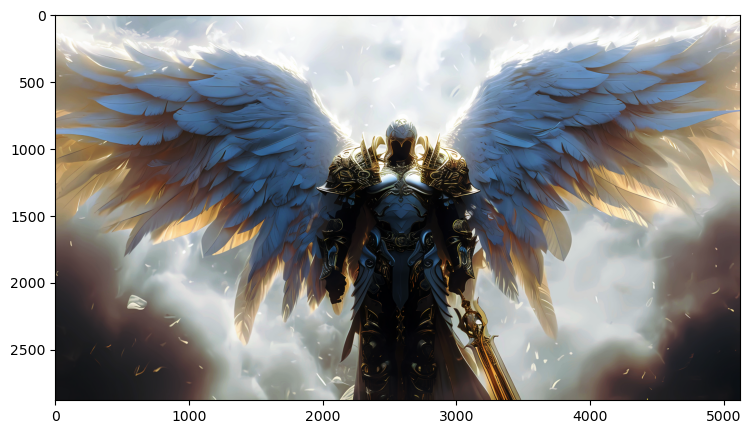

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Fond.jpg')

# Corrección: convertir a escala de grises antes de equalizeHist
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ecualizado = cv2.equalizeHist(gray)

# Corrección: ecualizar cada canal por separado (correcto, pero aseguramos que img sea color)
ecu_color = cv2.merge([
    cv2.equalizeHist(img[:,:,0]),
    cv2.equalizeHist(img[:,:,1]),
    cv2.equalizeHist(img[:,:,2])
])

plt.imshow(ecualizado, cmap='gray')
plt.show()

plt.imshow(cv2.cvtColor(ecu_color, cv2.COLOR_BGR2RGB))
plt.show()

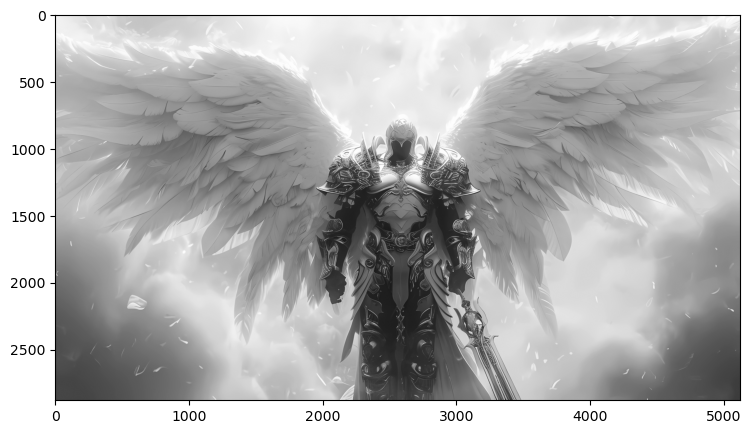

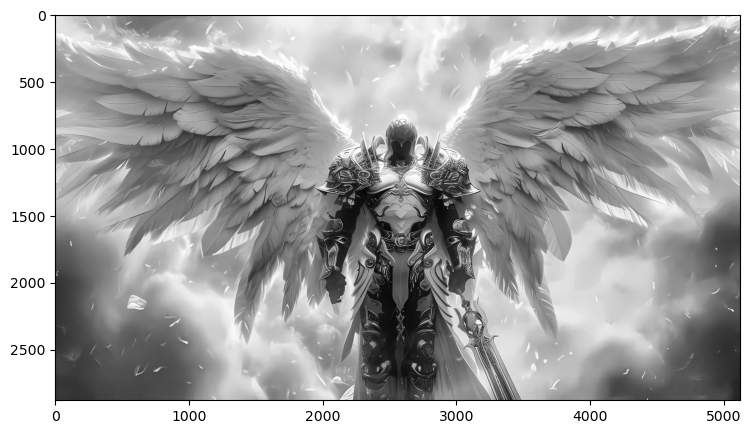

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imge= cv2.imread('Fond.jpg',0)
clip=2.0
tiles=8

clahe=cv2.createCLAHE(clipLimit=clip, tileGridSize=(tiles,tiles))
ecualizado = clahe.apply(imge)

plt.imshow(imge,cmap='gray')
plt.show()
plt.imshow(ecualizado,cmap='gray')
plt.show()


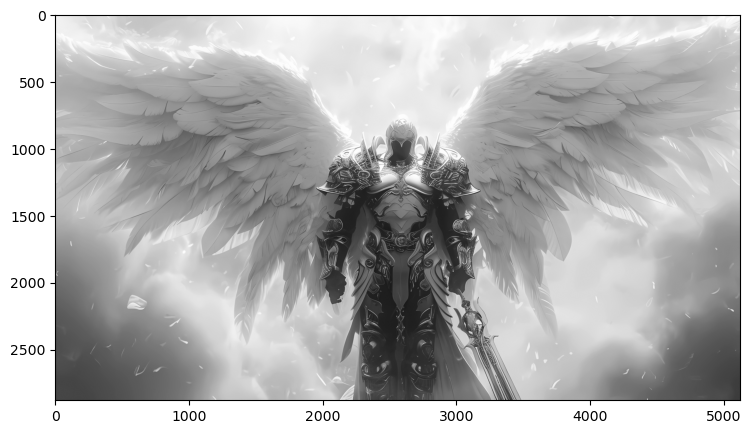

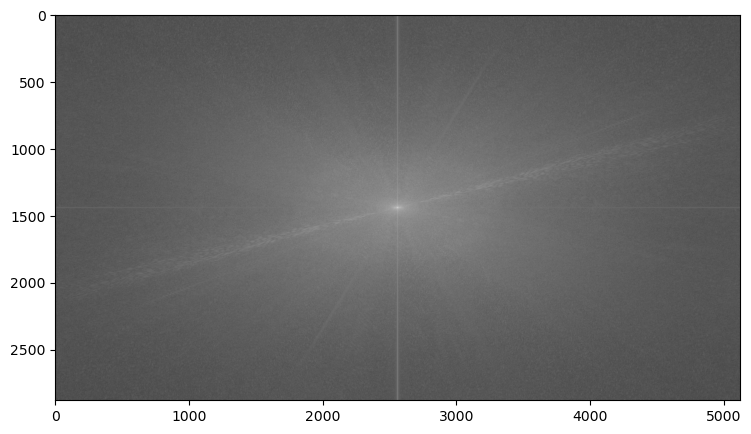

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imge= cv2.imread('Fond.jpg',0)
transformado=np.fft.fft2(imge)
desplazamiento=np.fft.fftshift(transformado)
magnitud_espectro=np.log(1+np.abs(desplazamiento))

plt.imshow(imge,cmap='gray')
plt.show()
plt.imshow(magnitud_espectro,cmap='gray')
plt.show()